<a href="https://colab.research.google.com/github/SAGNIK890/Predictive-Maintenance-and-Vehicle-Health-Monitoring-System/blob/main/Predictive_Maintenance_Vehicle_Health_Monitoring_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 AI/ML-Based Predictive Maintenance & Vehicle Health Monitoring

**Module 3 Connectivity Project — Project 1**

Goal: predict whether an engine requires maintenance from sensor readings, estimate failure probability, calculate a vehicle health score, and generate a maintenance alert.

This notebook uses a public Predictive Maintenance Engine Sensor Dataset from Hugging Face. The dataset contains 19,535 engine records and the target `Engine Condition` (0 = normal, 1 = maintenance/fault condition according to the dataset description).

**Dataset:** https://huggingface.co/datasets/mukherjee78/predictive-maintenance-engine-data

> Note: the project brief lists vibration, battery voltage, vehicle speed and operating hours as possible inputs. This dataset does not provide those columns, so this implementation uses the sensor columns actually present in the dataset rather than fabricating measurements.


In [1]:
# Install required packages
!pip -q install xgboost shap


In [2]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier

RANDOM_STATE = 42


## 1. Load the dataset


In [3]:
# Direct CSV download from Hugging Face
DATA_URL = 'https://huggingface.co/datasets/mukherjee78/predictive-maintenance-engine-data/resolve/main/raw_data.csv'

df = pd.read_csv(DATA_URL)

print('Dataset shape:', df.shape)
display(df.head())


Dataset shape: (19535, 7)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0


In [4]:
print('Columns:')
for col in df.columns:
    print('-', col)

print('\nMissing values:')
display(df.isnull().sum())

print('\nTarget distribution:')
display(df['Engine Condition'].value_counts().sort_index())


Columns:
- Engine rpm
- Lub oil pressure
- Fuel pressure
- Coolant pressure
- lub oil temp
- Coolant temp
- Engine Condition

Missing values:


,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0
Engine Condition,0



Target distribution:


,count
Engine Condition,
0,7218
1,12317


## 2. Basic exploratory data analysis


,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912
Engine Condition,19535.0,0.630509,0.482679,0.000000,0.000000,1.000000,1.000000,1.000000


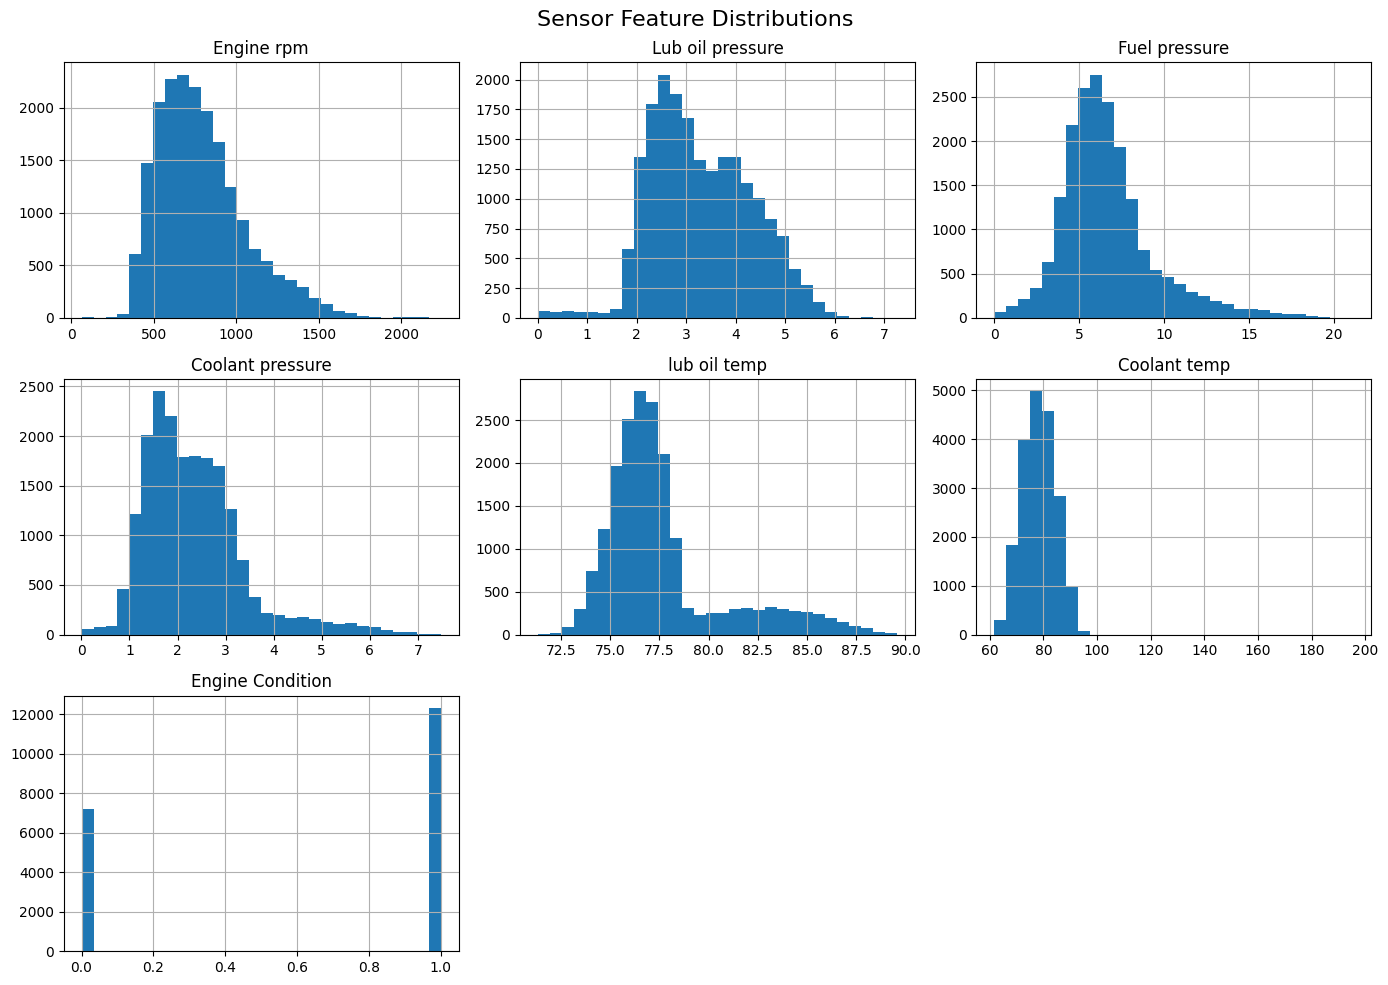

In [5]:
display(df.describe().T)

df.hist(figsize=(14, 10), bins=30)
plt.suptitle('Sensor Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()


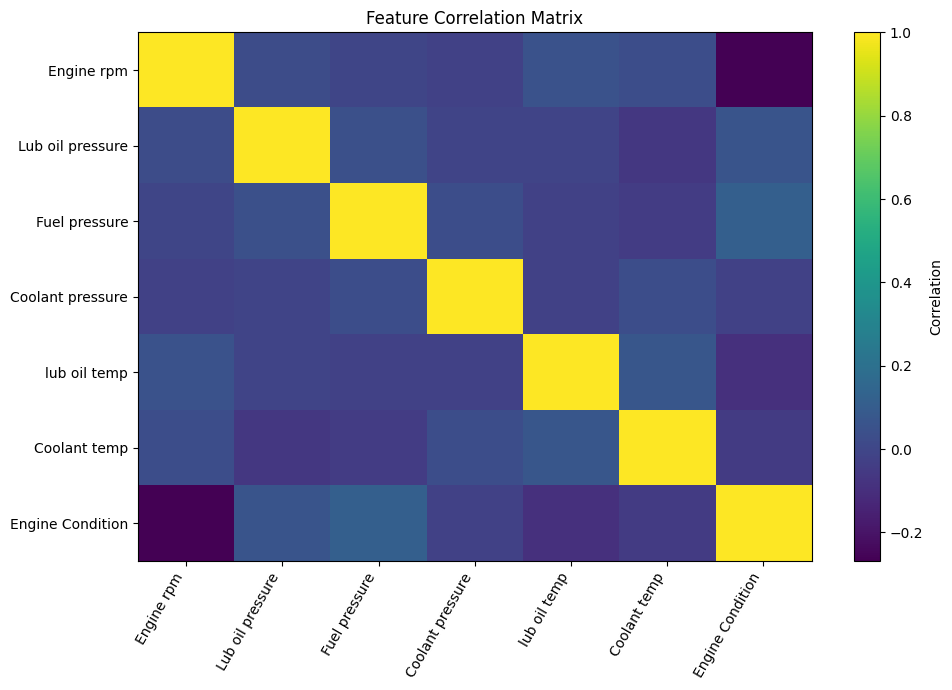

In [6]:
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
plt.imshow(corr, aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## 3. Prepare features and target

The target is `Engine Condition`. We use the sensor columns as model inputs.


In [7]:
TARGET = 'Engine Condition'

X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

feature_names = X.columns.tolist()

print('Features:', feature_names)
print('Target:', TARGET)
print('Classes:', sorted(y.unique()))


Features: ['Engine rpm', 'Lub oil pressure', 'Fuel pressure', 'Coolant pressure', 'lub oil temp', 'Coolant temp']
Target: Engine Condition
Classes: [np.int64(0), np.int64(1)]


## 4. Train / test split

Stratification keeps the class distribution approximately consistent between training and testing data.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))


Training samples: 15628
Testing samples : 3907


## 5. Build ML models


In [9]:
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),

    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    'XGBoost': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}


## 6. Train and evaluate all models


In [10]:
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    results.append(metrics)
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

display(results_df.style.format({c: '{:.4f}' for c in results_df.columns if c != 'Model'}))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.6668,0.6991,0.8274,0.7579,0.6975
0,Logistic Regression,0.6611,0.6787,0.8782,0.7657,0.6918
1,Random Forest,0.6511,0.6857,0.8246,0.7488,0.6812


## 7. Detailed evaluation of the Random Forest model


              precision    recall  f1-score   support

           0     0.5429    0.3553    0.4295      1444
           1     0.6857    0.8246    0.7488      2463

    accuracy                         0.6511      3907
   macro avg     0.6143    0.5899    0.5891      3907
weighted avg     0.6329    0.6511    0.6307      3907



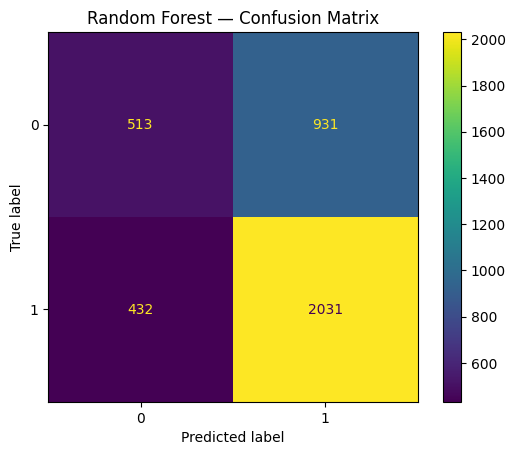

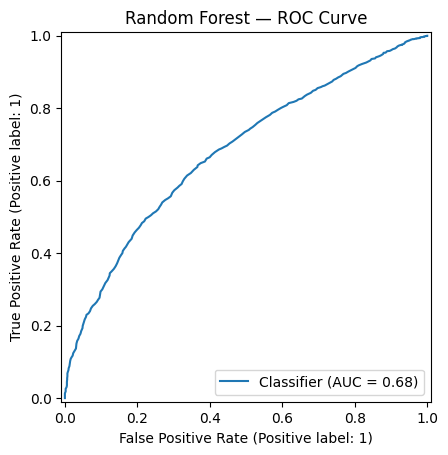

In [11]:
rf_model = trained_models['Random Forest']

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Random Forest — Confusion Matrix')
plt.show()

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.title('Random Forest — ROC Curve')
plt.show()


## 8. Feature importance — Explainable AI (XAI)


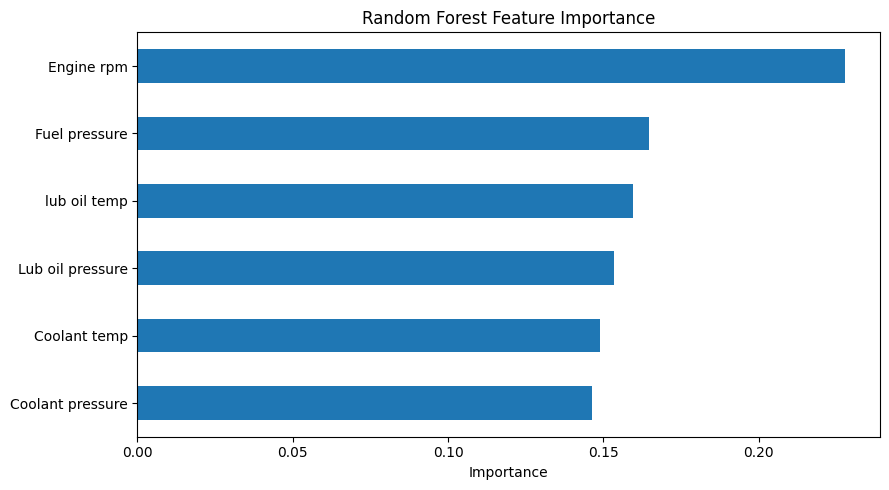

,Importance
Engine rpm,0.227639
Fuel pressure,0.164715
lub oil temp,0.159449
Lub oil pressure,0.153296
Coolant temp,0.148738
Coolant pressure,0.146163


In [12]:
rf_estimator = rf_model.named_steps['model']
importances = pd.Series(rf_estimator.feature_importances_, index=feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

display(importances.sort_values(ascending=False).to_frame('Importance'))


## 9. Failure probability → Vehicle Health Score

For this project demonstration:

- **Failure probability** = model probability of the maintenance/fault class.
- **Health score** = `100 × (1 − failure probability)`.
- Alert thresholds are demonstration thresholds and can be calibrated using validation data in a production system.


In [13]:
def health_status(failure_probability):
    if failure_probability >= 0.70:
        return 'CRITICAL'
    elif failure_probability >= 0.40:
        return 'WARNING'
    else:
        return 'HEALTHY'


monitoring_output = X_test.copy().reset_index(drop=True)
monitoring_output['Actual Condition'] = y_test.reset_index(drop=True)
monitoring_output['Failure Probability'] = rf_prob
monitoring_output['Vehicle Health Score'] = (100 * (1 - rf_prob)).clip(0, 100)
monitoring_output['Status'] = monitoring_output['Failure Probability'].apply(health_status)
monitoring_output['Maintenance Alert'] = monitoring_output['Status'].apply(
    lambda x: 'INSPECTION REQUIRED' if x in ['WARNING', 'CRITICAL'] else 'NO IMMEDIATE ACTION'
)

display(monitoring_output.head(20))


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Actual Condition,Failure Probability,Vehicle Health Score,Status,Maintenance Alert
0,634,2.611260,10.453517,2.771041,75.863640,79.245834,1,0.806667,19.333333,CRITICAL,INSPECTION REQUIRED
1,856,4.043840,5.829366,2.460446,73.860133,71.047078,1,0.620000,38.000000,WARNING,INSPECTION REQUIRED
2,814,4.073486,5.257120,1.866571,81.840070,76.715591,0,0.470000,53.000000,WARNING,INSPECTION REQUIRED
3,379,2.724639,4.712955,1.981593,77.092260,76.106727,1,0.926667,7.333333,CRITICAL,INSPECTION REQUIRED
4,868,2.672809,5.273917,1.905387,78.475478,72.088361,0,0.523333,47.666667,WARNING,INSPECTION REQUIRED
5,486,2.751187,4.981189,1.947335,77.915084,82.366213,1,0.703333,29.666667,CRITICAL,INSPECTION REQUIRED
6,584,2.017893,7.132055,2.591518,75.530132,76.892572,1,0.823333,17.666667,CRITICAL,INSPECTION REQUIRED
7,642,3.958400,6.737429,1.969273,77.925034,66.415888,1,0.756667,24.333333,CRITICAL,INSPECTION REQUIRED
8,1041,4.521053,6.210473,3.187334,79.197006,71.817446,0,0.543333,45.666667,WARNING,INSPECTION REQUIRED
9,1427,2.843245,4.407384,2.191826,75.031977,78.144296,0,0.320000,68.000000,HEALTHY,NO IMMEDIATE ACTION


## 10. Single-vehicle prediction function


In [14]:
def predict_vehicle_health(sensor_values, model=rf_model):
    """
    sensor_values: dictionary containing the dataset's six sensor features.
    Returns failure probability, health score and maintenance status.
    """
    row = pd.DataFrame([sensor_values], columns=feature_names)
    failure_probability = float(model.predict_proba(row)[0, 1])
    predicted_condition = int(model.predict(row)[0])
    health_score = float(np.clip(100 * (1 - failure_probability), 0, 100))
    status = health_status(failure_probability)

    return {
        'Predicted Condition': predicted_condition,
        'Failure Probability (%)': round(failure_probability * 100, 2),
        'Vehicle Health Score (%)': round(health_score, 2),
        'Status': status,
        'Maintenance Alert': 'INSPECTION REQUIRED' if status != 'HEALTHY' else 'NO IMMEDIATE ACTION'
    }


## 11. Test with a real sample from the dataset


In [15]:
sample_vehicle = X_test.iloc[0].to_dict()

print('Sensor values:')
for key, value in sample_vehicle.items():
    print(f'  {key}: {value}')

print('\nPrediction:')
prediction = predict_vehicle_health(sample_vehicle)
for key, value in prediction.items():
    print(f'  {key}: {value}')


Sensor values:
  Engine rpm: 634.0
  Lub oil pressure: 2.611259749
  Fuel pressure: 10.45351674
  Coolant pressure: 2.771041203
  lub oil temp: 75.86364036
  Coolant temp: 79.24583418

Prediction:
  Predicted Condition: 1
  Failure Probability (%): 80.67
  Vehicle Health Score (%): 19.33
  Status: CRITICAL
  Maintenance Alert: INSPECTION REQUIRED


## 12. Manual sensor-input prediction


In [16]:
# Change these values to test another hypothetical vehicle.
# Keep the feature names exactly as they appear in the dataset.

manual_vehicle = {
    'Engine rpm': 900,
    'Lub oil pressure': 3.5,
    'Fuel pressure': 8.0,
    'Coolant pressure': 2.5,
    'lub oil temp': 80.0,
    'Coolant temp': 80.0
}

manual_prediction = predict_vehicle_health(manual_vehicle)

print('===== VEHICLE HEALTH MONITOR =====')
print(f"Vehicle Health: {manual_prediction['Vehicle Health Score (%)']}%")
print(f"Failure Probability: {manual_prediction['Failure Probability (%)']}%")
print(f"Status: {manual_prediction['Status']}")
print(f"Maintenance Alert: {manual_prediction['Maintenance Alert']}")


===== VEHICLE HEALTH MONITOR =====
Vehicle Health: 38.67%
Failure Probability: 61.33%
Status: WARNING
Maintenance Alert: INSPECTION REQUIRED


## 13. Generate maintenance-alert summary

This converts model output into a simple dashboard-style result similar to the project brief: health percentage, failure probability, status and contributing factors.


In [17]:
def generate_alert(sensor_values, model=rf_model, top_n=3):
    row = pd.DataFrame([sensor_values], columns=feature_names)
    probability = float(model.predict_proba(row)[0, 1])
    score = float(np.clip(100 * (1 - probability), 0, 100))
    status = health_status(probability)

    # Global RF feature importance is used as a simple XAI contribution proxy.
    # For exact per-record explanations, use SHAP in the optional cell below.
    top_factors = importances.sort_values(ascending=False).head(top_n).index.tolist()

    return {
        'Vehicle Health': f'{score:.1f}%',
        'Failure Probability': f'{probability * 100:.1f}%',
        'Status': status,
        'Maintenance Alert': 'INSPECTION REQUIRED' if status != 'HEALTHY' else 'NO IMMEDIATE ACTION',
        'Major contributing factors': top_factors
    }

alert = generate_alert(manual_vehicle)

print('===== MAINTENANCE ALERT =====')
for key, value in alert.items():
    print(f'{key}: {value}')


===== MAINTENANCE ALERT =====
Vehicle Health: 38.7%
Failure Probability: 61.3%
Status: WARNING
Maintenance Alert: INSPECTION REQUIRED
Major contributing factors: ['Engine rpm', 'Fuel pressure', 'lub oil temp']


## 14. Optional SHAP explanation (XAI)

Run this cell if you want a local explanation for one prediction. SHAP shows how each sensor pushes the prediction toward or away from the maintenance/fault class.


In [18]:
import shap

X_train_imputed = pd.DataFrame(
    rf_model.named_steps['imputer'].transform(X_train),
    columns=feature_names
)

X_sample = pd.DataFrame([manual_vehicle], columns=feature_names)
X_sample_imputed = pd.DataFrame(
    rf_model.named_steps['imputer'].transform(X_sample),
    columns=feature_names
)

explainer = shap.TreeExplainer(rf_estimator)
shap_values = explainer.shap_values(X_sample_imputed)

if isinstance(shap_values, list):
    values_for_class_1 = shap_values[1][0]
else:
    values_for_class_1 = shap_values[0, :, 1] if shap_values.ndim == 3 else shap_values[0]

explanation = pd.DataFrame({
    'Feature': feature_names,
    'SHAP contribution': values_for_class_1
}).sort_values('SHAP contribution', key=np.abs, ascending=False)

display(explanation)


,Feature,SHAP contribution
2,Fuel pressure,0.104128
0,Engine rpm,-0.071344
3,Coolant pressure,0.049232
1,Lub oil pressure,0.042636
4,lub oil temp,-0.018539
5,Coolant temp,0.007005


## 15. Save the trained model and monitoring results


In [19]:
import joblib

joblib.dump(rf_model, 'predictive_maintenance_random_forest.pkl')
monitoring_output.to_csv('vehicle_health_predictions.csv', index=False)

print('Saved: predictive_maintenance_random_forest.pkl')
print('Saved: vehicle_health_predictions.csv')


Saved: predictive_maintenance_random_forest.pkl
Saved: vehicle_health_predictions.csv


## 16. Download outputs in Google Colab


In [20]:
from google.colab import files

files.download('predictive_maintenance_random_forest.pkl')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Project architecture implemented

Vehicle/Engine Sensors → Data Preprocessing → ML Model → Failure Probability → Vehicle Health Score → Maintenance Alert

### Models included
- Logistic Regression
- Random Forest
- XGBoost

### XAI included
- Random Forest feature importance
- Optional SHAP local explanation

### Main outputs
- Failure probability
- Vehicle health score
- Status: HEALTHY / WARNING / CRITICAL
- Maintenance alert
- Major contributing sensor factors


In [21]:


import os
import shutil
from google.colab import files

# Folder where all project outputs will be collected
OUTPUT_DIR = "/content/Predictive_Maintenance_Outputs"

# Remove old output folder if it exists
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR)

print("Collecting all project outputs...")



import matplotlib.pyplot as plt

# If figures are currently open, save them
fig_numbers = plt.get_fignums()

for i, fig_num in enumerate(fig_numbers, start=1):
    fig = plt.figure(fig_num)
    graph_path = os.path.join(
        OUTPUT_DIR,
        f"graph_{i}.png"
    )
    fig.savefig(
        graph_path,
        dpi=300,
        bbox_inches="tight"
    )

print(f"Saved {len(fig_numbers)} currently open graphs.")




try:
    results_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "model_comparison_results.csv"
        ),
        index=False
    )
    print("✓ Model comparison results saved")
except Exception as e:
    print("Model comparison results not available:", e)




try:
    monitoring_output.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "vehicle_health_predictions.csv"
        ),
        index=False
    )
    print("✓ Vehicle health predictions saved")
except Exception as e:
    print("Vehicle health predictions not available:", e)




try:
    feature_importance_df = (
        importances
        .sort_values(ascending=False)
        .to_frame(name="Importance")
    )

    feature_importance_df.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "feature_importance.csv"
        )
    )

    print("✓ Feature importance saved")
except Exception as e:
    print("Feature importance not available:", e)




try:
    explanation.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "SHAP_explanation.csv"
        ),
        index=False
    )

    print("✓ SHAP explanation saved")
except Exception as e:
    print("SHAP explanation not available:", e)




try:
    import joblib

    joblib.dump(
        rf_model,
        os.path.join(
            OUTPUT_DIR,
            "predictive_maintenance_random_forest.pkl"
        )
    )

    print("✓ Random Forest model saved")
except Exception as e:
    print("Model not available:", e)




summary_path = os.path.join(
    OUTPUT_DIR,
    "project_summary.txt"
)

with open(summary_path, "w", encoding="utf-8") as f:

    f.write("""
AI/ML-BASED PREDICTIVE MAINTENANCE
AND VEHICLE HEALTH MONITORING SYSTEM
=====================================

Project Outputs
---------------

Models:
1. Logistic Regression
2. Random Forest
3. XGBoost

Machine Learning Outputs:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve

Vehicle Monitoring:
- Failure Probability
- Vehicle Health Score
- Vehicle Status
- Maintenance Alert

XAI:
- Random Forest Feature Importance
- SHAP Explanation

Architecture:
Vehicle Sensors
      ↓
Data Preprocessing
      ↓
ML Model
      ↓
Failure Probability
      ↓
Vehicle Health Score
      ↓
Maintenance Alert

Dataset:
Predictive Maintenance Engine Sensor Dataset

Dataset URL:
https://huggingface.co/datasets/mukherjee78/predictive-maintenance-engine-data
""")

print("✓ Project summary saved")




try:

    possible_notebooks = [
        "/content/Predictive_Maintenance_Vehicle_Health_Monitoring_Colab.ipynb"
    ]

    for notebook in possible_notebooks:
        if os.path.exists(notebook):
            shutil.copy(
                notebook,
                OUTPUT_DIR
            )
            print("✓ Notebook copied")
            break

except Exception as e:
    print("Notebook copy skipped:", e)




print("\n========================================")
print("        GENERATED PROJECT FILES")
print("========================================")

for root, dirs, filenames in os.walk(OUTPUT_DIR):

    for filename in filenames:

        filepath = os.path.join(root, filename)

        size_kb = os.path.getsize(filepath) / 1024

        print(
            f"✓ {filename:<45} "
            f"{size_kb:>8.2f} KB"
        )



ZIP_NAME = "/content/Predictive_Maintenance_Project_Outputs"

shutil.make_archive(
    ZIP_NAME,
    "zip",
    OUTPUT_DIR
)

ZIP_FILE = ZIP_NAME + ".zip"

print("\n========================================")
print("              ZIP CREATED")
print("========================================")

print(f"File: {ZIP_FILE}")

size_mb = os.path.getsize(ZIP_FILE) / (1024 * 1024)

print(f"Size: {size_mb:.2f} MB")



print("\nDownloading ZIP...")

files.download(ZIP_FILE)

print("\n ALL PROJECT OUTPUTS DOWNLOADED!")

Saved 0 currently open graphs.
✓ Model comparison results saved
✓ Vehicle health predictions saved
✓ Feature importance saved
✓ SHAP explanation saved
✓ Random Forest model saved
✓ Project summary saved

        GENERATED PROJECT FILES
✓ vehicle_health_predictions.csv                  476.45 KB
✓ model_comparison_results.csv                      0.36 KB
✓ project_summary.txt                               0.78 KB
✓ feature_importance.csv                            0.21 KB
✓ predictive_maintenance_random_forest.pkl      146610.94 KB
✓ SHAP_explanation.csv                              0.23 KB

              ZIP CREATED
File: /content/Predictive_Maintenance_Project_Outputs.zip
Size: 31.94 MB



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 ALL PROJECT OUTPUTS DOWNLOADED!
